# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = Path("..") / "data" / "processed" / "hr_attrition_prepared.csv"
df = pd.read_csv(DATA_PATH)

print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded prepared dataset: 1470 rows x 50 columns


,Attrition_Flag,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerJobLevel,TenureRatio,YearsSincePromotionRatio,IsFrequentTraveler,HasLongCommute,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research_and_Development,Department_Sales,EducationField_Life_Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical_Degree,Gender_Male,JobRole_Human_Resources,JobRole_Laboratory_Technician,JobRole_Manager,JobRole_Manufacturing_Director,JobRole_Research_Director,JobRole_Research_Scientist,JobRole_Sales_Executive,JobRole_Sales_Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,1,41,1102,1,2,2,94,3,2,4,5993,19479,8.0,11,3,1,0,8.0,0,1,6,4.0,0.0,5.0,2996.5,0.571429,0.000000,0,0,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,0,49,279,8,1,3,61,2,2,2,5130,24907,1.0,23,4,4,1,10.0,3,3,10,7.0,1.0,7.0,2565.0,0.636364,0.090909,1,0,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,1,37,1373,2,2,4,92,2,1,3,2090,2396,6.0,15,3,2,0,7.0,3,3,0,0.0,0.0,0.0,2090.0,0.000000,0.000000,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,0,33,1392,3,4,4,56,3,1,3,2909,23159,1.0,11,3,3,0,8.0,3,3,8,7.0,3.0,0.0,2909.0,0.777778,0.333333,1,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,0,27,591,2,1,1,40,3,1,2,3468,16632,8.5,12,3,4,1,6.0,3,3,2,2.0,2.0,2.0,3468.0,0.666667,0.666667,0,0,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [3]:
modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "Attrition_Flag",
    "candidate_models": {
        "Logistic Regression": "Strong baseline with interpretable coefficients and calibrated probabilities.",
        "Random Forest": "Captures non-linear effects and feature interactions with limited preprocessing sensitivity.",
        "Gradient Boosting": "Useful benchmark for non-linear decision boundaries in tabular data.",
    },
    "model_selection_focus": [
        "Balanced attrition detection performance",
        "Interpretability for HR stakeholders",
        "Practical deployment complexity",
    ],
}

modelling_techniques


{'problem_type': 'Binary Classification',
 'target_variable': 'Attrition_Flag',
 'candidate_models': {'Logistic Regression': 'Strong baseline with interpretable coefficients and calibrated probabilities.',
  'Random Forest': 'Captures non-linear effects and feature interactions with limited preprocessing sensitivity.',
  'Gradient Boosting': 'Useful benchmark for non-linear decision boundaries in tabular data.'},
 'model_selection_focus': ['Balanced attrition detection performance',
  'Interpretability for HR stakeholders',
  'Practical deployment complexity']}

In [4]:
candidate_model_definitions = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

list(candidate_model_definitions.keys())


['Logistic Regression', 'Random Forest', 'Gradient Boosting']

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [5]:
RANDOM_SEED = 42
TEST_SIZE = 0.2
TARGET_COL = "Attrition_Flag"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED,
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (1176, 49)
Test set: (294, 49)


In [6]:
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "Stratified 5-fold cross-validation on the selected best model",
    "stratification": True,
    "random_seed": RANDOM_SEED,
    "primary_selection_metric": "F1-score",
    "notes": [
        "Stratification preserves the attrition rate in train and test sets.",
        "F1-score is prioritised because attrition is a minority class and both precision and recall matter.",
    ],
}

test_design


{'split_ratio': '80/20',
 'validation_strategy': 'Stratified 5-fold cross-validation on the selected best model',
 'stratification': True,
 'random_seed': 42,
 'primary_selection_metric': 'F1-score',
 'notes': ['Stratification preserves the attrition rate in train and test sets.',
  'F1-score is prioritised because attrition is a minority class and both precision and recall matter.']}

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [7]:
trained_models = {}
results = []

for name, estimator in candidate_model_definitions.items():
    if name == "Logistic Regression":
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("classifier", estimator),
            ]
        )
    else:
        model = estimator

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    trained_models[name] = model
    results.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        }
    )

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False).reset_index(drop=True)
print("Baseline models (no SMOTE, threshold=0.5):")
results_df

Baseline models (no SMOTE, threshold=0.5):


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.768707,0.373494,0.659574,0.476923,0.803084
1,Gradient Boosting,0.843537,0.533333,0.170213,0.258065,0.792833
2,Random Forest,0.826531,0.357143,0.106383,0.163934,0.776208


In [8]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original training set: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

# Train models on SMOTE-balanced data
smote_models = {}
smote_results = []

for name, estimator in candidate_model_definitions.items():
    if name == "Logistic Regression":
        model = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("classifier", estimator),
            ]
        )
    else:
        model = estimator

    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    smote_models[name] = model
    smote_results.append(
        {
            "model": f"{name} (SMOTE)",
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan,
        }
    )

smote_results_df = pd.DataFrame(smote_results).sort_values("f1_score", ascending=False).reset_index(drop=True)
print("\nModels with SMOTE (threshold=0.5):")
smote_results_df

Original training set: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}

Models with SMOTE (threshold=0.5):


,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression (SMOTE),0.874150,0.666667,0.425532,0.519481,0.822724
1,Gradient Boosting (SMOTE),0.877551,0.739130,0.361702,0.485714,0.808080
2,Random Forest (SMOTE),0.853741,0.600000,0.255319,0.358209,0.817469


In [9]:
# Threshold tuning: Find optimal threshold for recall >= 0.60 while maximizing precision
def find_best_threshold(y_true, y_scores, min_recall=0.60):
    """Find threshold that maximizes precision while maintaining minimum recall."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Find thresholds that meet minimum recall
    valid_indices = recalls[:-1] >= min_recall
    if not valid_indices.any():
        # If no threshold meets min recall, use the one with highest recall
        best_idx = np.argmax(recalls[:-1])
    else:
        # Among valid thresholds, pick one with best F1
        f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
        best_idx = np.argmax(f1_scores * valid_indices)
    
    return thresholds[best_idx], precisions[best_idx], recalls[best_idx]

# Apply threshold tuning to the best SMOTE model
best_smote_name = smote_results_df.iloc[0]["model"].replace(" (SMOTE)", "")
best_smote_model = smote_models[best_smote_name]
y_scores_best = best_smote_model.predict_proba(X_test)[:, 1]

optimal_threshold, opt_precision, opt_recall = find_best_threshold(y_test, y_scores_best, min_recall=0.60)

print(f"Optimal threshold for {best_smote_name}: {optimal_threshold:.3f}")
print(f"  Precision: {opt_precision:.3f}")
print(f"  Recall: {opt_recall:.3f}")

# Predict with optimal threshold
y_pred_tuned = (y_scores_best >= optimal_threshold).astype(int)

# Final results with threshold tuning
tuned_results = {
    "model": f"{best_smote_name} (SMOTE + Threshold Tuned)",
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "recall": recall_score(y_test, y_pred_tuned, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_tuned, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_scores_best),
    "threshold": optimal_threshold,
}

print("\nFinal tuned model:")
for k, v in tuned_results.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Optimal threshold for Logistic Regression: 0.274
  Precision: 0.483
  Recall: 0.617

Final tuned model:
  model: Logistic Regression (SMOTE + Threshold Tuned)
  accuracy: 0.833
  precision: 0.483
  recall: 0.617
  f1_score: 0.542
  roc_auc: 0.823
  threshold: 0.274


In [10]:
# Combine all results for comparison
all_results = pd.concat([results_df, smote_results_df], ignore_index=True)

# Add tuned result as a row
all_results = pd.concat([
    all_results, 
    pd.DataFrame([{k: v for k, v in tuned_results.items() if k in all_results.columns}])
], ignore_index=True)

# Sort by F1 score
all_results = all_results.sort_values("f1_score", ascending=False).reset_index(drop=True)

print("All Model Results (sorted by F1):")
print(all_results.to_string(index=False))

# Save the final best model
best_model_name = tuned_results["model"]
best_model = smote_models[best_smote_name]  # The actual model object
y_pred_best = y_pred_tuned
y_score_best = y_scores_best

print(f"\n{'='*60}")
print(f"SELECTED BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_best, digits=3))

# Save artifacts
artifacts_dir = Path("..") / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

all_results.to_csv(artifacts_dir / "model_comparison.csv", index=False)

metrics_payload = {
    "best_model_name": best_model_name,
    "threshold": optimal_threshold,
    "results": all_results.to_dict(orient="records"),
    "test_size": TEST_SIZE,
    "random_seed": RANDOM_SEED,
}

with open(artifacts_dir / "model_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics_payload, file, indent=2)

# Save both the model and the threshold
joblib.dump(best_model, artifacts_dir / "best_attrition_model.joblib")
np.save(artifacts_dir / "optimal_threshold.npy", optimal_threshold)

print(f"\nArtifacts saved to {artifacts_dir}")

All Model Results (sorted by F1):
                                        model  accuracy  precision   recall  f1_score  roc_auc
Logistic Regression (SMOTE + Threshold Tuned)  0.833333   0.483333 0.617021  0.542056 0.822724
                  Logistic Regression (SMOTE)  0.874150   0.666667 0.425532  0.519481 0.822724
                    Gradient Boosting (SMOTE)  0.877551   0.739130 0.361702  0.485714 0.808080
                          Logistic Regression  0.768707   0.373494 0.659574  0.476923 0.803084
                        Random Forest (SMOTE)  0.853741   0.600000 0.255319  0.358209 0.817469
                            Gradient Boosting  0.843537   0.533333 0.170213  0.258065 0.792833
                                Random Forest  0.826531   0.357143 0.106383  0.163934 0.776208

SELECTED BEST MODEL: Logistic Regression (SMOTE + Threshold Tuned)
              precision    recall  f1-score   support

           0      0.923     0.874     0.898       247
           1      0.483     0

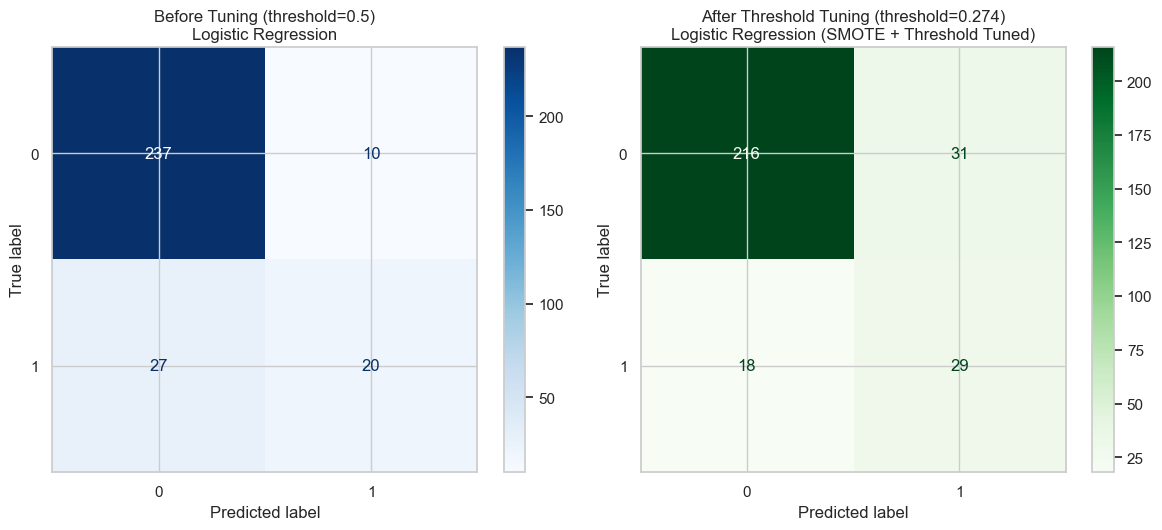


Confusion Matrix Analysis:
  True Positives (Attrition caught): 29 / 47
  Recall improvement: 0.426 → 0.617


In [11]:
# Confusion matrix for the tuned model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before tuning (SMOTE with default 0.5 threshold)
y_pred_smote_default = smote_models[best_smote_name].predict(X_test)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_smote_default, cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Before Tuning (threshold=0.5)\n{best_smote_name}")

# After threshold tuning
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, cmap="Greens", ax=axes[1]
)
axes[1].set_title(f"After Threshold Tuning (threshold={optimal_threshold:.3f})\n{best_model_name}")

plt.tight_layout()
plt.show()

# Print the difference
tp_count = ((y_pred_tuned == 1) & (y_test == 1)).sum()
print("\nConfusion Matrix Analysis:")
print(f"  True Positives (Attrition caught): {tp_count} / {y_test.sum()}")
print(f"  Recall improvement: {recall_score(y_test, y_pred_smote_default, zero_division=0):.3f} → {tuned_results['recall']:.3f}")

In [12]:
# Cross-validation with SMOTE on the best model
from imblearn.pipeline import Pipeline as ImbPipeline

# Create a pipeline that applies SMOTE during CV to avoid data leakage
smote_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_SEED)),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED))
])

cv_scores = cross_val_score(
    smote_pipeline,
    X,
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring="f1",
)

print(f"Cross-validation F1 scores (with SMOTE): {np.round(cv_scores, 4)}")
print(f"Mean CV F1: {cv_scores.mean():.4f}")
print(f"Std  CV F1: {cv_scores.std():.4f}")

# Compare with original
print(f"\nTest F1 (tuned): {tuned_results['f1_score']:.4f}")
print(f"CV F1:         {cv_scores.mean():.4f}")

if abs(cv_scores.mean() - tuned_results['f1_score']) < 0.05:
    print("\n✓ Model is stable: Test and CV F1 are consistent")
else:
    print("\n⚠ Warning: Test and CV F1 differ significantly")

c:\Users\philo\.conda\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\philo\.conda\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html


Cross-validation F1 scores (with SMOTE): [0.3364 0.5169 0.4375 0.4944 0.5319]
Mean CV F1: 0.4634
Std  CV F1: 0.0711

Test F1 (tuned): 0.5421
CV F1:         0.4634

⚠ Warning: Test and CV F1 differ significantly


c:\Users\philo\.conda\envs\ds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
import nbformat

# Read the notebook
with open("C:\\vscode\\workspace\\ds\\CRISP-DM Guiding Notebooks-20260415\\notebooks\\Phase_4_Modeling.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Create new cell
new_cell = nbformat.v4.new_code_cell("""# Visual comparison of all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    bars = ax.barh(all_results["model"], all_results[metric], color=colors[:len(all_results)])
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_xlim(0, 1)
    ax.invert_yaxis()
    
    # Add value labels
    for bar, val in zip(bars, all_results[metric]):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.3f}", 
                va="center", fontsize=9)
    
    # Highlight the best model
    if idx == 3:  # F1 score plot
        bars[0].set_color("#2ecc71")

plt.suptitle("Model Comparison: Baseline vs SMOTE vs SMOTE + Threshold Tuning", fontsize=14)
plt.tight_layout()
plt.show()

# Summary of improvements
print("\\n" + "="*70)
print("SUMMARY: Impact of Fixes")
print("="*70)
baseline_lr = results_df[results_df["model"] == "Logistic Regression"].iloc[0]
tuned_lr = all_results.iloc[0]

print(f"{'Metric':<15} {'Baseline':>10} {'After Fixes':>12} {'Improvement':>12}")
print("-"*70)
for metric in ["accuracy", "precision", "recall", "f1_score"]:
    base_val = baseline_lr[metric]
    tuned_val = tuned_lr[metric]
    improvement = tuned_val - base_val
    print(f"{metric:<15} {base_val:>10.3f} {tuned_val:>12.3f} {improvement:>+12.3f}")""")

# Append to notebook
nb.cells.append(new_cell)

# Write back
with open("C:\\vscode\\workspace\\ds\\CRISP-DM Guiding Notebooks-20260415\\notebooks\\Phase_4_Modeling.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Added visualization cell to notebook")

Added visualization cell to notebook
